# Exercise 5: Gradient Descent Implementation

Complete implementation following quiz requirements.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

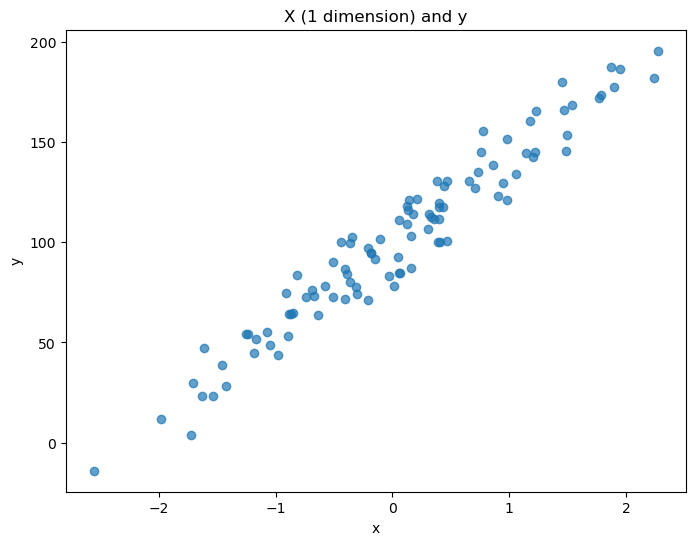

In [2]:
# Generate exact dataset as specified
X, y, coef = make_regression(n_samples=100, n_features=1, n_informative=1, 
                           noise=10, coef=True, random_state=0, bias=100.0)

# Plot data
plt.figure(figsize=(8, 6))
plt.scatter(X.reshape(1,-1)[0], y, alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('X (1 dimension) and y')
plt.show()

In [3]:
def compute_mse(coefs, X, y):
    '''
    coefs is a list that contains a and b: [a,b]
    X is the features set
    y is the target
    Returns a float which is the MSE
    '''
    a, b = coefs
    y_preds = a * X.reshape(1,-1)[0] + b
    mse = np.mean((y_preds - y) ** 2)
    return mse

print(f"MSE for a=1, b=2: {compute_mse([1, 2], X, y)}")

MSE for a=1, b=2: 11808.867339751561


In [4]:
# Create grid with 640000 points
aa, bb = np.mgrid[-200:200:0.5, -200:200:0.5]
grid = np.c_[aa.ravel(), bb.ravel()]
print(f"Grid contains {len(grid)} points")

Grid contains 640000 points


In [5]:
# Compute MSE for all grid points
losses = [compute_mse(coef_pair, X, y) for coef_pair in grid]
print(f"Computed {len(losses)} MSE values")

Computed 640000 MSE values


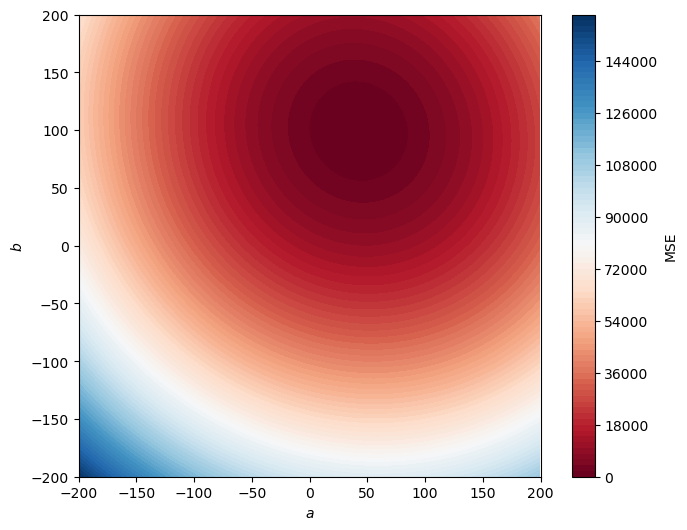

In [6]:
# Plot MSE contour as specified
losses_reshaped = np.array(losses).reshape(aa.shape)

f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(aa, bb, losses_reshaped, 100, cmap="RdBu", vmin=0, vmax=160000)
ax_c = f.colorbar(contour)
ax_c.set_label("MSE")
ax.set(aspect="equal", xlim=(-200, 200), ylim=(-200, 200), xlabel="$a$", ylabel="$b$")
plt.show()

In [7]:
# Find optimal values from grid search
min_idx = np.argmin(losses)
optimal_a, optimal_b = grid[min_idx]
optimal_mse = losses[min_idx]
print(f"Grid Search best a: {optimal_a} b: {optimal_b} MSE: {optimal_mse}")

Grid Search best a: 42.5 b: 99.0 MSE: 114.22320947849832


In [8]:
# Gradient descent with learning_rate=0.1, iterations=100
a, b = 0.0, 0.0
params_history = np.zeros((100, 2))
X_flat = X.reshape(1,-1)[0]

for i in range(100):
    y_pred = a * X_flat + b
    da = (2/len(y)) * np.sum((y_pred - y) * X_flat)
    db = (2/len(y)) * np.sum(y_pred - y)
    a -= 0.1 * da
    b -= 0.1 * db
    params_history[i] = [a, b]

gd_mse = compute_mse([a, b], X, y)
print(f"Gradient Descent a: {a} b: {b} MSE: {gd_mse}")

Gradient Descent a: 42.61943031121357 b: 99.18581814447936 MSE: 114.17148616819485


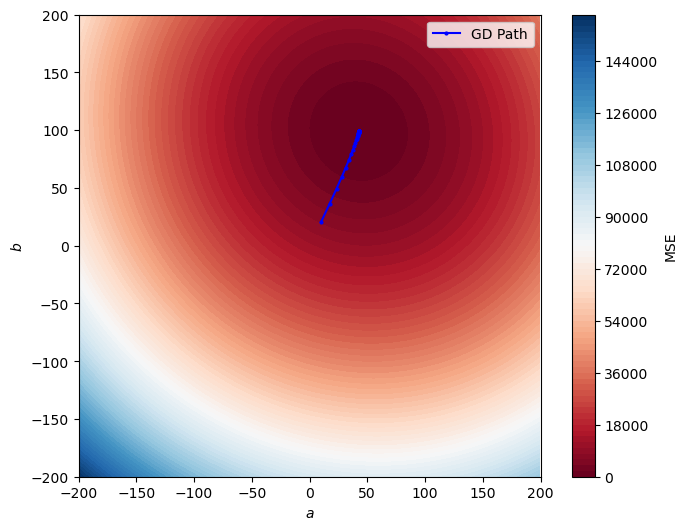

In [9]:
# Plot convergence path on contour
f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(aa, bb, losses_reshaped, 100, cmap="RdBu", vmin=0, vmax=160000)
ax_c = f.colorbar(contour)
ax_c.set_label("MSE")
ax.plot(params_history[:, 0], params_history[:, 1], 'bo-', markersize=2, label='GD Path')
ax.set(aspect="equal", xlim=(-200, 200), ylim=(-200, 200), xlabel="$a$", ylabel="$b$")
plt.legend()
plt.show()

In [10]:
# Scikit-learn Linear Regression comparison
lr = LinearRegression()
lr.fit(X, y)
sklearn_a, sklearn_b = lr.coef_[0], lr.intercept_
sklearn_mse = compute_mse([sklearn_a, sklearn_b], X, y)

print(f"Scikit-learn a: {sklearn_a} b: {sklearn_b} MSE: {sklearn_mse}")
print(f"\nComparison:")
print(f"Grid Search:     MSE = {optimal_mse:.3f}")
print(f"Gradient Descent: MSE = {gd_mse:.3f}")
print(f"Scikit-learn:    MSE = {sklearn_mse:.3f}")

Scikit-learn a: 42.61943029136694 b: 99.18581817296929 MSE: 114.17148616819486

Comparison:
Grid Search:     MSE = 114.223
Gradient Descent: MSE = 114.171
Scikit-learn:    MSE = 114.171
